In [1]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer

In [2]:
BASE_DIR = r'C:\Users\LENOVO\Desktop\Structural_Damage_Detection\archive_'

filepaths = []
components = []
statuses = []

In [ ]:
comp_list = ['Decks', 'Pavements', 'Walls']
status_list = ['Cracked', 'Non-cracked']

for comp in comp_list:
    for status in status_list:
        dir_path = os.path.join(BASE_DIR, comp, status)
        
        if os.path.exists(dir_path):
            for file in os.listdir(dir_path):
                if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    filepaths.append(os.path.join(dir_path, file))
                    components.append(comp)       
                    statuses.append(status)      

🔍 Klasörler taranıyor...


In [ ]:
df = pd.DataFrame({
    'Image_Path': filepaths,
    'Component': components,
    'Status': statuses
})

print(f"Toplam {len(df)} adet resim başarıyla bulundu. / A total of {len(df)} images were found successfully")
print("\nVeri Setinden İlk 5 Örnek: / Top 5 Samples from the Dataset:")
display(df.head())

✅ Toplam 56092 adet resim başarıyla bulundu!

Veri Setinden İlk 5 Örnek:


,Image_Path,Component,Status
0,C:\Users\LENOVO\Desktop\Structural_Damage_Dete...,Decks,Cracked
1,C:\Users\LENOVO\Desktop\Structural_Damage_Dete...,Decks,Cracked
2,C:\Users\LENOVO\Desktop\Structural_Damage_Dete...,Decks,Cracked
3,C:\Users\LENOVO\Desktop\Structural_Damage_Dete...,Decks,Cracked
4,C:\Users\LENOVO\Desktop\Structural_Damage_Dete...,Decks,Cracked


In [ ]:
lb_comp = LabelBinarizer()
labels_component = lb_comp.fit_transform(df['Component'])

lb_status = LabelBinarizer()
labels_status = lb_status.fit_transform(df['Status'])

print("\nKategoriler sayısallaştırıldı: / Categories have been digitized:")
print(f"Yapı Türü Sınıfları: / Building Type Classes {lb_comp.classes_}")
print(f"Durum Sınıfları  / Status Classes  : {lb_status.classes_}")


Kategoriler sayısallaştırıldı:
Yapı Türü Sınıfları: ['Decks' 'Pavements' 'Walls']
Durum Sınıfları    : ['Cracked' 'Non-cracked']


In [6]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Input, Dropout
from tensorflow.keras.models import Model

In [ ]:
(train_paths, val_paths, 
 train_comp, val_comp, 
 train_status, val_status) = train_test_split(
    df['Image_Path'].values, 
    labels_component, 
    labels_status, 
    test_size=0.2, 
    random_state=42
)

Veriler Eğitim (%80) ve Doğrulama (%20) olarak ayrılıyor...


In [ ]:
BATCH_SIZE = 32

@tf.function
def process_data(img_path, comp_label, status_label):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [224, 224]) / 255.0
    
    targets = (comp_label, status_label)
    return img, targets

In [ ]:
train_dataset = tf.data.Dataset.from_tensor_slices((train_paths, train_comp, train_status))
train_dataset = train_dataset.map(process_data, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.shuffle(2000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((val_paths, val_comp, val_status))
val_dataset = val_dataset.map(process_data, num_parallel_calls=tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [ ]:
print("Model inşa ediliyor. / The model is being built")
input_tensor = Input(shape=(224, 224, 3), name='image_input')
base_model = ResNet50(weights='imagenet', include_top=False, input_tensor=input_tensor)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
shared_features = GlobalAveragePooling2D()(x)
shared_features = Dropout(0.3)(shared_features)

Model inşa ediliyor...


In [ ]:
out_component = Dense(3, activation='softmax', name='component_out')(shared_features)

out_status = Dense(1, activation='sigmoid', name='status_out')(shared_features)


dual_task_model = Model(inputs=input_tensor, outputs=[out_component, out_status])


dual_task_model.compile(
    optimizer='adam',
    loss={
        'component_out': 'categorical_crossentropy',
        'status_out': 'binary_crossentropy'
    },

    metrics={
        'component_out': 'accuracy',
        'status_out': 'accuracy'
    }
)

In [ ]:
EPOCHS = 5
print("training")

history = dual_task_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    steps_per_epoch=50,
    validation_steps=20
)

🚀 Eğitim Başlıyor!
Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 114s 2s/step - component_out_accuracy: 0.4456 - component_out_loss: 1.0525 - loss: 1.4703 - status_out_accuracy: 0.8581 - status_out_loss: 0.4178 - val_component_out_accuracy: 0.4359 - val_component_out_loss: 0.9895 - val_loss: 1.4651 - val_status_out_accuracy: 0.8234 - val_status_out_loss: 0.4755
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 127s 3s/step - component_out_accuracy: 0.5100 - component_out_loss: 0.9953 - loss: 1.4493 - status_out_accuracy: 0.8444 - status_out_loss: 0.4540 - val_component_out_accuracy: 0.5750 - val_component_out_loss: 0.9651 - val_loss: 1.4416 - val_status_out_accuracy: 0.8234 - val_status_out_loss: 0.4765
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 131s 3s/step - component_out_accuracy: 0.4731 - component_out_loss: 0.9929 - loss: 1.4299 - status_out_accuracy: 0.8456 - status_out_loss: 0.4370 - val_component_out_accuracy: 0.6219 - val_component_out_loss: 0.9811 - val_loss: 1.4510 - val_status_out_accuracy: 0.8234 - v

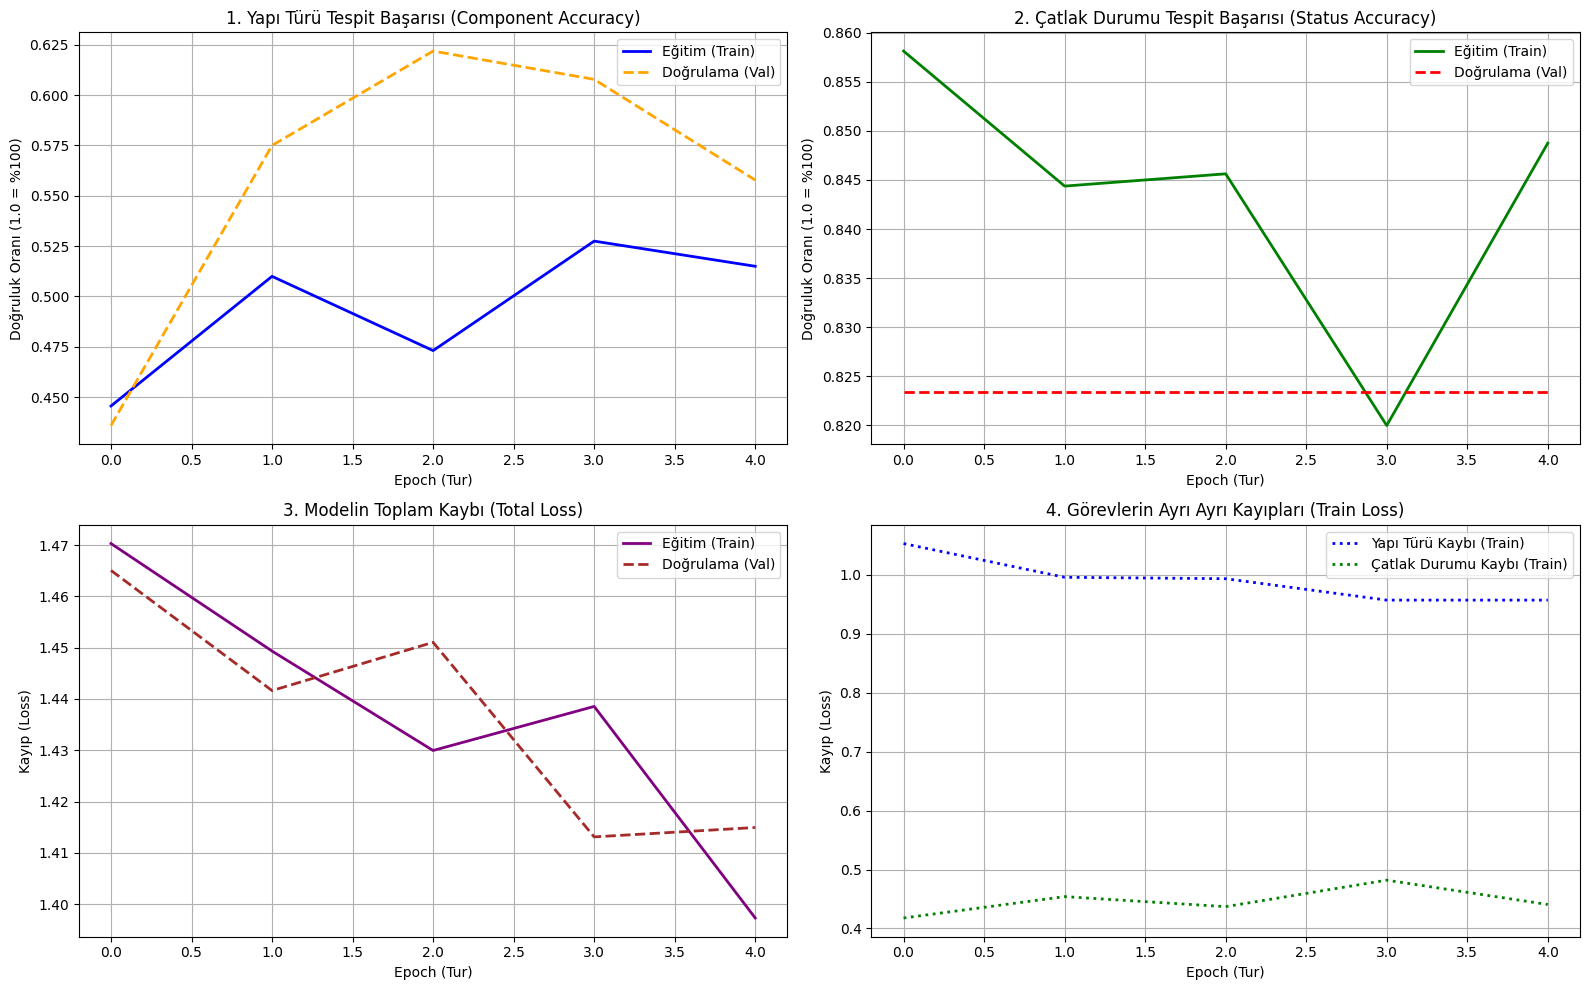

In [ ]:
import matplotlib.pyplot as plt

h = history.history

plt.figure(figsize=(16, 10))

plt.subplot(2, 2, 1)
plt.plot(h['component_out_accuracy'], label='Eğitim (Train)', linewidth=2, color='blue')
plt.plot(h['val_component_out_accuracy'], label='Doğrulama (Val)', linewidth=2, linestyle='--', color='orange')
plt.title('1. Yapı Türü Tespit Başarısı (Component Accuracy)')
plt.xlabel('Epoch (Tur)')
plt.ylabel('Doğruluk Oranı / accuracy rate(1.0 = %100)')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(h['status_out_accuracy'], label='Eğitim (Train)', linewidth=2, color='green')
plt.plot(h['val_status_out_accuracy'], label='Doğrulama (Val)', linewidth=2, linestyle='--', color='red')
plt.title('2. Çatlak Durumu Tespit Başarısı (Status Accuracy)')
plt.xlabel('Epoch (Tur)')
plt.ylabel('Doğruluk Oranı / accuracy rate (1.0 = %100)')
plt.legend()
plt.grid(True)


plt.subplot(2, 2, 3)
plt.plot(h['loss'], label='Eğitim (Train)', linewidth=2, color='purple')
plt.plot(h['val_loss'], label='Doğrulama (Val)', linewidth=2, linestyle='--', color='brown')
plt.title('3. Modelin Toplam Kaybı (Total Loss)')
plt.xlabel('Epoch (Tur)')
plt.ylabel('Kayıp (Loss)')
plt.legend()
plt.grid(True)


plt.subplot(2, 2, 4)
plt.plot(h['component_out_loss'], label='Yapı Türü Kaybı (Train)', linewidth=2, color='blue', linestyle=':')
plt.plot(h['status_out_loss'], label='Çatlak Durumu Kaybı (Train)', linewidth=2, color='green', linestyle=':')
plt.title('4. Görevlerin Ayrı Ayrı Kayıpları (Train Loss)')
plt.xlabel('Epoch (Tur)')
plt.ylabel('Kayıp (Loss)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

🔍 Yapay Zeka Resmi İnceliyor...
3060/3060 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step

🏗️ YAPI UZMANI ANALİZ SONUCU
📍 Yapı Elemanı Tahmini : Walls (Duvar)
🔎 Çatlak Durumu        : Çatlak Var ⚠️


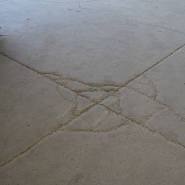

In [ ]:
import numpy as np
import tensorflow as tf


URL = "data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQABAAD/2wCEAAkGBwgHBgkIBwgKCgkLDRYPDQwMDRsUFRAWIB0iIiAdHx8kKDQsJCYxJx8fLT0tMTU3Ojo6Iys/RD84QzQ5OjcBCgoKDQwNGg8PGjclHyU3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3N//AABEIAKgAtAMBIgACEQEDEQH/xAAbAAACAwEBAQAAAAAAAAAAAAAAAgEDBAUGB//EADsQAAIBAgMFBQUGBQUBAAAAAAABAgMRBBIhBRMxQXEiMlFhgUJykaGxBiQzYsHRFSNS8PE0U3OC4RT/xAAYAQEBAQEBAAAAAAAAAAAAAAAAAQIDBP/EABsRAQEBAQEBAQEAAAAAAAAAAAABEQISMQMh/9oADAMBAAIRAxEAPwDgpjqVhnSuRu5cjztmUhlqVZZINVowq9N8hlOzszOpDqYXWmNUsjVMikNcz5XWxVdSxVDApWGVQl5XXQVQZTMMaug6qGcXW1TGzmNVdBlUJitecnOZVUJzjBpzk5zNnJzgaMwZzNnDOBozkZyjeaEZ9ANGcDLnADBlDKWJBlOzkrykZC22oZQKXTXNEbpcjRlIygZ3TfIjLOPe4GmxGUChSGuWuEXxQjpLlowFuSpEZJLQV6aMLq3OMqhRmDOTF1pVQdVDHvBamIhTSc5W6mbF1v3mpOc58a8HqnoOqyfAmK2ZwzmRVdBlUGDTnIczM5hnIrRnIM7mAGmxKQ6Qc7WudXMtgsJvXUbhRjns7ZpaRj+/QdUpqNpVZXfNRX7AI6cJTcnq1pa/AZQXK1urLI01BZY3svF3JsQV5SitiaNCapzk3UeqhGLk2uiNTWW7dkubZzqdWOJ2jCrh6blShCUJVbaS4WS8dUyi+hVVWnvJUqkOOk1r8Lk72k1dySX5tPqaVEiUU9GtBpjPvKThvFOLj/VmVjJLHQnNQwkJYiT/ANvurrJ6fV+RrrYHD1mnUgpJcmtC3IktEkuSXIaME1XcNMPFy/5LL42/QqpxrJSdVQT5KDudGUSqcQObia8qSvbTS/I5+KqzrTbV2/B8Eb9qw+7T09TJaMZ9ltpvmZ6XlVvqkH2qbfnB3LKeM177j7yaLnT1B009Gro5a6Ghi5clfzuWrGf1Jr5mZ0YezHKyHTktFJ+pZ0mN0MRCfdne3KxZvLnLakvMRtxejnB+TaNekx194ByViKiVt7frEgeoj11ga05XXiOkQ0dGWTZLcsDBytvM081vHM7/ADNtnzOfhIyhtWrGjG9CrDNUlyjNafFr6HTsKqu2pNh7BYgRxTTUr2enoZsHBwwtKErXhHK7PmtC/E75UZPDKm6q4Kei8/8ABXhKO5w6g5uctXKT9pt3b+LAsUdAsWWCxBXl0FaLrENBWeUSucdDTKJVKOhZRydpQ+7y6GClHSPU6+0I/d59Dl04W1M9rFzjqGXQteoZTk0psK0XtCNAUyRXKJe0JJAZ3DUC2wFZessZtpVZ4fBzqU+/pl0vd34LzfD4GtIrxFDf0J07uOZaSXGL5NHdzZ8NgZYWM1hqzUZtzaqLMrt3v/4Wwxai1HFR3Unwb7svUswtTe0c0tJp5Zx8JFrUZRcZq6emqv8AILKmwspWaikpS83wRkqKpgb1KMZVaN9aS1lHl2dfkXYaq60d7KjOi3plna/rYDJPE4qvWlQpYVU4RnllVqS4r8qRuy9ljJXlcexFIloQ4a5s0tOXIssFgEtoRYdohoiq5ISSLWhZIDDjI3ps40VZ+p3sSuw+hw1xZnpeWmxFh+S6A0cm1bRDWgzI5FFbRXJFzRXIqKrASyQj1dgCxKO7ky13ucTQqrhUlu5+FrNp/FfM1rRGSvTlWx1CEnalFOpZe1JNW18Fe5r9bgRPLkefRJXv4cyvM2ouOrk9LfUTGfzI/wDzcd6u15RXH9v8F9OnGEVkVlyQUihVdZSkssEmklLi/H5Ft7ku/MAoDkAciCCBiCKVoRljElwAx4v8KRw1zO9ie4/dOF7XqZ6WNSWi6IkI91e6DOTRZCjPgQyhGVy4FjEkBWBIGoj1ObwJuULI9VJX8mTaXKT9Ud/44rKsrU5TSvKCzL9v78QoS3lGnLnKKk11EvKzV009NCqjvaOGUMic4Rskn4cP78wLMJee8rSXbcnF+WVmlcCjCxSpJ+3LWXvWLr+BFiQIuFwupALgFBBJBBDEkOxJAZ667Euljgc31O/W7kuhwX331M9NRqjwj0IZFPuxJbOTSGKSQ+ICsRlj4FbCFAh8SQOrDaOAq93EQ/7aF0KlGX4VWL92Z5F01bVIrcEtUrPyZ6GfD215L2n0auWUtePJ8jw8a1em/wCXXrQ6SZfT2ptKlrHEt+8rg8V7Ok7uo/Px8kWnkKP2hx9J9qFCor34WPWwvkje17a2KzZhhZ8iQIieRFwuABcL6EAwsDYkmDYsgaqrS0OBfty6s7lbgzg+3LqzPTUaab7CGuVw7qJbOWNGuQ2LcL6ADFZPIVsBW9SRWAFlXBYPVUsTBe82mLHZU5U51KdTMoq/Ykn+p3MbsjCyqzjRxcWlJpXa8TPX+y9aWDqYilUpSjT1d/JN/obnTtZMeWqqcJK8Lq3OJRvY84v0N1XZ+Mpz/lKWiS7MvIzRoYzMlKlKV3ZZopr6HWSONthqGHr4iDnSw9ScU+KWh7yF1FJ8UrGPZ1J4fBUaUmm4x1srI1lzHK9aa4CoYlQXAh8Q5EUPiQAAQxJMaQkuAFNTmcKX4kurO7U5nBqfiz95mel5Xw7sepJXT7q6jXOboli3B8SL6gSxG9RmIwIbAgAPoOJ2RhK03u8RHW9lmXiZcb9mZ09l18TSrxSindWavp5Hra+zqVeLy1Yyv5pnK2r9nq0Nn1KtCtGKs9LNX5fqeedV67Jn186r4HaNOpU3Na6Wls3L1K6P8Yg4pQi4/mSaXWzN+O2ftWnOvKjVvFNt9vlfzMkf41TtBxi4v2pJNJW8n5nu5rydzHZoZ9zDeNOVtcvAtTEpqSpxU7ZkknbgOjo4mC5AXMiQIuFyCSGRcggGJIZvUSQVVUOFV/Hl77O5V4HFrf6ifUz0vJo9z1JZEX2PUJHNsMW5DYADYrJbFCgCAA+6VtlqXCSv+aBz9o7JxUcK91VjFNpWi2r3aADzTia7z9Osx4HaOD2vGFaUJ3jbVZk/qc6rU21QjJToRsl3pRVlZeT8AA9f5s/p8dKF8izWvbkMAHoeNIABlQRcAIC4MgCUQxGAAVTONX/HkAEvxrlF+yyLkgcmytkXACiCG9SAIIbAAA//2Q=="
resim_yolu = tf.keras.utils.get_file(origin=URL)

img = tf.keras.utils.load_img(resim_yolu, target_size=(224, 224)) 
img_array = np.expand_dims(tf.keras.utils.img_to_array(img) / 255.0, axis=0)


tahminler = dual_task_model.predict(img_array)


comp_pred = tahminler[0]   # Building Type Possibilities
status_pred = tahminler[1] # Çatlak İhtimali (0 ile 1 arası) / Probability of Crack (between 0 and 1


comp_labels = ['Decks (Döşeme)', 'Pavements (Kaldırım)', 'Walls (Duvar)']
secilen_yapi = comp_labels[np.argmax(comp_pred)]


catlak_durumu = "Çatlak Var / Crack" if status_pred[0][0] > 0.5 else "Sağlam / No Crack"

# Sonuç Ekranı
print("\n" + "="*40)
print("YAPI UZMANI ANALİZ SONUCU / BUILDING EXPERT ANALYSIS RESULT")
print("="*40)
print(f"Yapı Elemanı Tahmini : / Building Element Estimation: {secilen_yapi}")
print(f"Çatlak Durumu / Crack Condition : {catlak_durumu}")
print("="*40 + "\n")

In [23]:
dual_task_model.save('sdnet_component_model.keras')